In [6]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
import matplotlib.ticker as mticker
from calc import sqrt_p_to_tick, tick_to_p


def plot(
    ticks_a: list[int],
    ticks_b: list[int],
    liqs_a: list[int],
    liqs_b: list[int],
    tick_a: int,
    tick_b: int,
    tick_a_after_swap: int,
    tick_b_after_swap: int,
    inv: bool = False,
    # 소수 자릿수 보정 배율 10**(token1.decimal - token0.decimal)
    mul: int = 1,
):
    assert tick_a <= tick_b, "tick a > tick b"

    plt.figure(figsize=(10, 4))

    # X축에 가격 표시
    plt.gca().xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda t, _: f"{int(mul/tick_to_p(t) if inv else mul*tick_to_p(t)):,}\n{t:.0f}"
        )
    )
    if inv:
        plt.gca().invert_xaxis()

    plt.step(
        ticks_a, liqs_a, where="post", linewidth=2, label="풀 a", color="tab:blue"
    )
    plt.step(
        ticks_b, liqs_b, where="post", linewidth=2, label="풀 b", color="tab:orange"
    )

    plt.axvline(tick_a, linewidth=1.5, color="tab:cyan", label=f"틱 a = {tick_a}")
    plt.axvline(tick_b, linewidth=1.5, color="tab:pink", label=f"틱 b = {tick_b}")
    plt.axvline(
        tick_a_after_swap,
        linewidth=1.5,
        color="tab:green",
        label=f"스왑 후 틱 a = {tick_a_after_swap}",
    )
    plt.axvline(
        tick_b_after_swap,
        linewidth=1.5,
        color="tab:purple",
        label=f"스왑 후 틱 b = {tick_b_after_swap}",
    )

    plt.gca().set_xlim(tick_a - 100, tick_b + 100)

    plt.xlabel("틱")
    plt.ylabel("유동성")
    plt.title("Uniswap 풀")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

tick a: 199911 tick b: 200585
dya: 4.6731757163482166e+20 dyb: 4.829309991161526e+20 sa: 22595.334669925447 sb: 22631.996858547216
dyb - dya: 1.561342748133091e+19
tick a after swap: 200520
tick b after swap: 200552


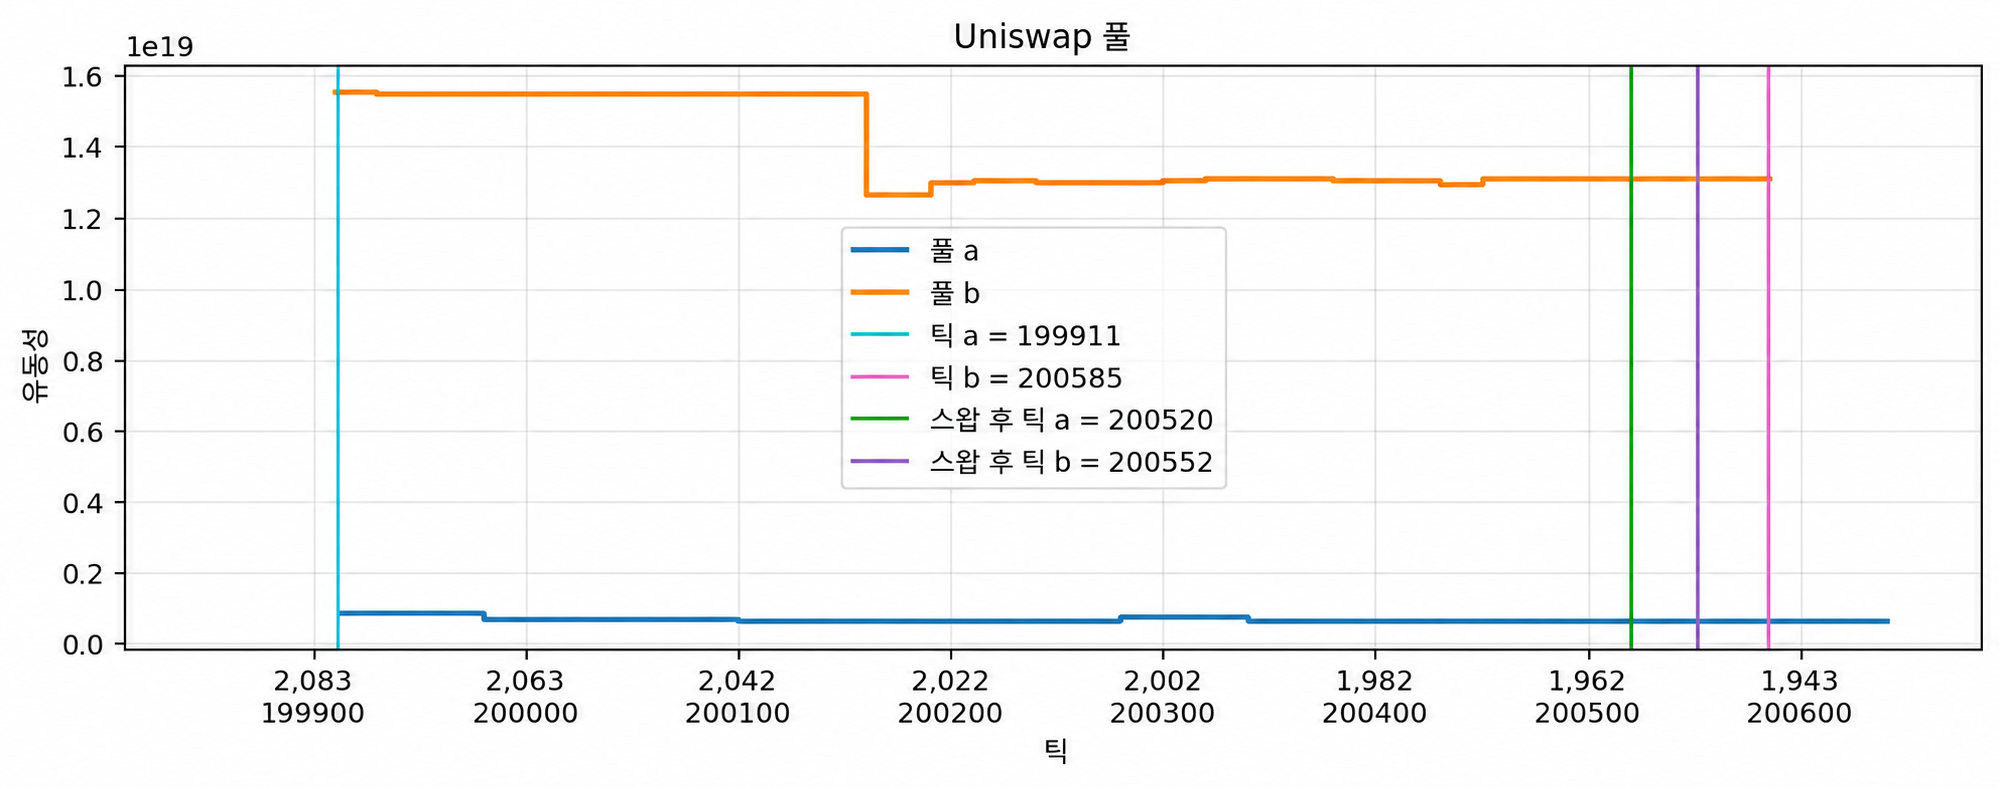

In [7]:
from calc import calc_dya
from data import build, get, map_sqrt

# 실제 데이터를 사용한 시뮬레이션
fee_a = 0.0005
fee_b = 0.003

ticks_a, liqs_a, pool_a = build(get("tmp/pool_a.json"), True)
ticks_b, liqs_b, pool_b = build(get("tmp/pool_b.json"), False)

# 첫 번째 틱의 하한
tick_a = pool_a[0][0]
# 첫 번째 틱의 상한
tick_b = pool_b[0][1]

print("tick a:", tick_a, "tick b:", tick_b)

(dya, dyb, sa, sb) = calc_dya(
    map_sqrt(pool_a),
    map_sqrt(pool_b),
    fee_a,
    fee_b,
)

print("dya:", dya, "dyb:", dyb, "sa:", sa, "sb:", sb)
print("dyb - dya:", dyb - dya)

tick_a_after_swap = sqrt_p_to_tick(sa)
tick_b_after_swap = sqrt_p_to_tick(sb)

print("tick a after swap:", tick_a_after_swap)
print("tick b after swap:", tick_b_after_swap)

plot(
    ticks_a,
    ticks_b,
    liqs_a,
    liqs_b,
    tick_a,
    tick_b,
    tick_a_after_swap,
    tick_b_after_swap,
    inv=True,
    mul=1e12,
)

sim dya: 35.59116795486824 dyb: 36.27002061107681 sa: 0.997509407115045 sb: 0.9992588922163088
dyb - dya: 0.6788526562085693
tick a after swap: -50
tick b after swap: -15


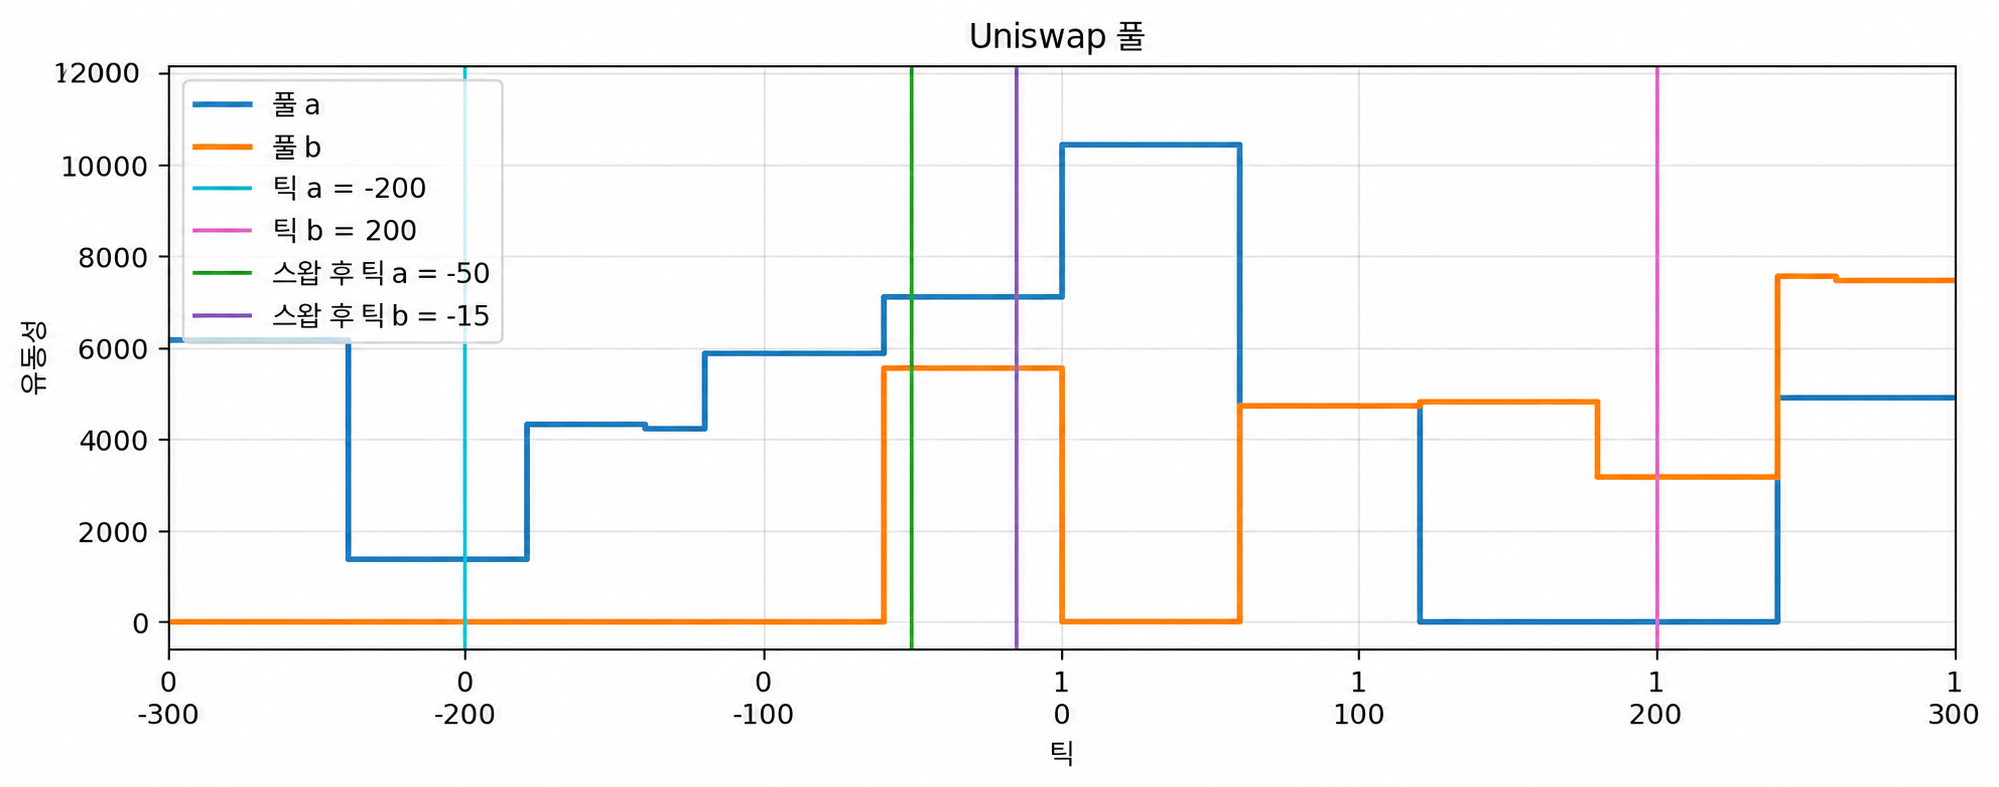

In [8]:
# 무작위 데이터를 사용한 시뮬레이션

import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from calc import tick_to_sqrt_p

# 수수료 등급 | 일반적인 틱 간격
# -------- | --------------------
# 0.05%    | 1
# 0.3%     | 60
# 1%       | 200
# 10%      | 2000

TICK_SPACING_A = 60
TICK_SPACING_B = 60
FEE_A = 0.003
FEE_B = 0.0005
TICK_A = -200
TICK_B = 200


def random_positions(
    n_positions,
    tick_min=-500,
    tick_max=500,
    tick_spacing=10,
    min_width=20,
    max_width=200,
    min_liquidity=0,
    max_liquidity=6000,
):
    positions = []
    # tick_min과 tick_max를 틱 간격에 맞춤
    tick_min = (tick_min // tick_spacing) * tick_spacing
    tick_max = (tick_max // tick_spacing) * tick_spacing
    for _ in range(n_positions):
        # 하한 틱을 tick_spacing의 배수로 생성
        lower = (
            random.randint(
                tick_min // tick_spacing, (tick_max - min_width) // tick_spacing
            )
            * tick_spacing
        )
        # 틱 너비를 무작위로 정한 뒤 상한을 맞춤
        width = random.randint(min_width, max_width)
        upper = lower + width
        # 상한을 틱 간격에 맞춤
        upper = ((upper + tick_spacing - 1) // tick_spacing) * tick_spacing
        if upper > tick_max:
            upper = tick_max
        liquidity = random.randint(min_liquidity, max_liquidity)
        positions.append((lower, upper, liquidity))
    return positions


def build_liq(positions):
    liq_net = defaultdict(float)
    for lower, upper, L in positions:
        liq_net[lower] += L
        liq_net[upper] -= L
    ticks = np.array(sorted(liq_net.keys()))
    delta = np.array([liq_net[t] for t in ticks])
    liqs = np.cumsum(delta)
    # [(하한 틱, 상한 틱, 유동성)]
    pool = []
    for i in range(len(ticks) - 1):
        if liqs[i] == 0:
            continue
        pool.append((ticks[i], ticks[i + 1], liqs[i]))
    return ticks, liqs, pool


def prep(pool, tick, up):
    # 검사
    t = -math.inf
    for lo, hi, L in pool:
        assert t <= lo < hi
        t = lo
    # 구간 추출
    s = []
    if up:
        assert any(lo <= tick <= hi for lo, hi, L in pool)
        s = [(lo, hi, L) for lo, hi, L in pool if tick < hi]
        assert len(s) > 0
        # print(up, s)
        (lo, hi, L) = s[0]
        assert lo <= tick
        s[0] = (tick, hi, L)
    else:
        assert any(lo <= tick <= hi for lo, hi, L in pool)
        s = [(lo, hi, L) for lo, hi, L in pool if lo < tick]
        assert len(s) > 0
        # print(up, s)
        (lo, hi, L) = s[-1]
        assert hi >= tick
        s[-1] = (lo, tick, L)
        s.reverse()
    # 변환
    return [
        (tick_to_sqrt_p(tick_lo), tick_to_sqrt_p(tick_hi), L)
        for tick_lo, tick_hi, L in s
    ]


def prep(pool, tick, up):
    # 구간 추출
    s = []
    if up:
        assert any(lo <= tick <= hi for lo, hi, L in pool)
        s = [(lo, hi, L) for lo, hi, L in pool if tick < hi]
        assert len(s) > 0
        # print(up, s)
        (lo, hi, L) = s[0]
        assert lo <= tick
        s[0] = (tick, hi, L)
    else:
        assert any(lo <= tick <= hi for lo, hi, L in pool)
        s = [(lo, hi, L) for lo, hi, L in pool if lo < tick]
        assert len(s) > 0
        # print(up, s)
        (lo, hi, L) = s[-1]
        assert hi >= tick
        s[-1] = (lo, tick, L)
        s.reverse()
    # 변환
    return [
        (tick_to_sqrt_p(tick_lo), tick_to_sqrt_p(tick_hi), L)
        for tick_lo, tick_hi, L in s
    ]


def round_tick(tick, tick_spacing):
    return (tick // tick_spacing) * tick_spacing


pool_a_positions = random_positions(n_positions=10, tick_spacing=TICK_SPACING_A)
pool_a_positions.append(
    (
        round_tick(TICK_A - TICK_SPACING_A, TICK_SPACING_A),
        round(TICK_A + TICK_SPACING_A, TICK_SPACING_A),
        100,
    )
)
pool_b_positions = random_positions(n_positions=10, tick_spacing=TICK_SPACING_B)
pool_b_positions.append(
    (
        round_tick(TICK_B - TICK_SPACING_B, TICK_SPACING_B),
        round(TICK_B + TICK_SPACING_B, TICK_SPACING_B),
        100,
    )
)

ticks_a, liqs_a, pool_a = build_liq(pool_a_positions)
ticks_b, liqs_b, pool_b = build_liq(pool_b_positions)

pool_a = prep(pool_a, TICK_A, True)
pool_b = prep(pool_b, TICK_B, False)

(dya, dyb, sa, sb) = calc_dya(pool_a, pool_b, FEE_A, FEE_B)
print("sim", "dya:", dya, "dyb:", dyb, "sa:", sa, "sb:", sb)
print("dyb - dya:", dyb - dya)

tick_a_after_swap = sqrt_p_to_tick(sa)
tick_b_after_swap = sqrt_p_to_tick(sb)

print("tick a after swap:", tick_a_after_swap)
print("tick b after swap:", tick_b_after_swap)

plot(
    ticks_a,
    ticks_b,
    liqs_a,
    liqs_b,
    TICK_A,
    TICK_B,
    tick_a_after_swap,
    tick_b_after_swap,
)

In [10]:
from calc import tick_to_p

1 / tick_to_p(200391), 1 / tick_to_p(200459), 1 / tick_to_p(200394)

(1.9841045918840132e-09, 1.970659119335549e-09, 1.983509479532886e-09)